# RegimeShift: Macro-Aware Tactical Asset Allocation Engine
### Summer of Quant — Advanced Capstone

**Pipeline:** data → features → HMM regime detection (walk-forward) → regime-conditional
convex optimization → transaction-cost-aware backtest → benchmark comparison.

This notebook is the single top-to-bottom deliverable. The actual logic lives in `src/`
(a small package: `data.py`, `features.py`, `regime.py`, `optimize.py`, `backtest.py`,
`metrics.py`, `walkforward.py`) — this notebook imports and runs it, and is where all
the plots/analysis/results live. See `README.md` for design decisions and how to
reproduce results.

**The one rule everything below obeys:** a decision made *as of* day `t` may only use
data known by the start of day `t`. Every rolling/expanding window, every z-score, every
HMM fit, and every mu/sigma estimate is built to respect that.


## 1. Setup & data

In [1]:
 pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys, warnings
sys.path.insert(0, ".")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.data import load_data
from src.features import build_feature_matrix, compute_log_returns, HMM_FEATURE_COLS
from src.backtest import run_walk_forward_regimes, run_backtest, static_benchmark_returns
from src.metrics import performance_summary

pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (12, 5)


In [3]:
# Live NSE + gold + bond-proxy + India VIX data. If this environment has no network
# access, `load_data` automatically falls back to a synthetic dataset (with a printed
# warning) so the rest of the notebook still runs end to end for review purposes.
# Swap START_DATE / tickers in src/data.py::DEFAULT_TICKERS as needed.

START_DATE = "2015-01-01"
END_DATE = None  # None = up to today

prices, vix = load_data(start=START_DATE, end=END_DATE)
print(prices.shape, vix.shape)
prices.tail()


[data] Loaded live data: 2846 rows, 2015-01-01 -> 2026-07-09
(2846, 3) (2823,)


,equity,bond,gold
Date,,,
2026-07-03,275.910004,1000.00000,120.309998
2026-07-06,277.429993,999.98999,119.510002
2026-07-07,277.049988,1000.00000,118.580002
2026-07-08,271.690002,1000.00000,116.959999
2026-07-09,272.760010,999.98999,118.419998


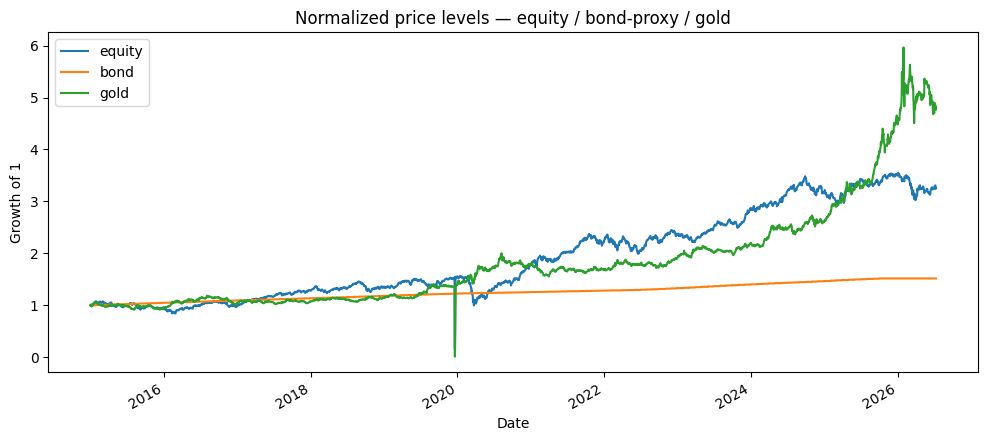

In [4]:
fig, ax = plt.subplots()
(prices / prices.iloc[0]).plot(ax=ax)
ax.set_title("Normalized price levels — equity / bond-proxy / gold")
ax.set_ylabel("Growth of 1")
plt.show()


## 2. Returns & sanity check

Convert to log returns, then eyeball the two "known-crisis" style windows the
2015–2024-ish NSE/global period contains (2020 COVID crash, 2022 rate-hike drawdown)
to confirm the data actually shows the stress we expect before building anything
clever on top of it.

In [5]:
asset_returns = compute_log_returns(prices).dropna()
asset_returns.describe()


,equity,bond,gold
count,2843.000000,2843.000000,2843.000000
mean,0.000413,0.000147,0.000550
std,0.061654,0.000698,0.122575
min,-2.295293,-0.000880,-4.606540
25%,-0.004057,0.000000,-0.003848
50%,0.000697,0.000000,0.000226
75%,0.005497,0.000009,0.005016
max,2.299434,0.005302,4.605170


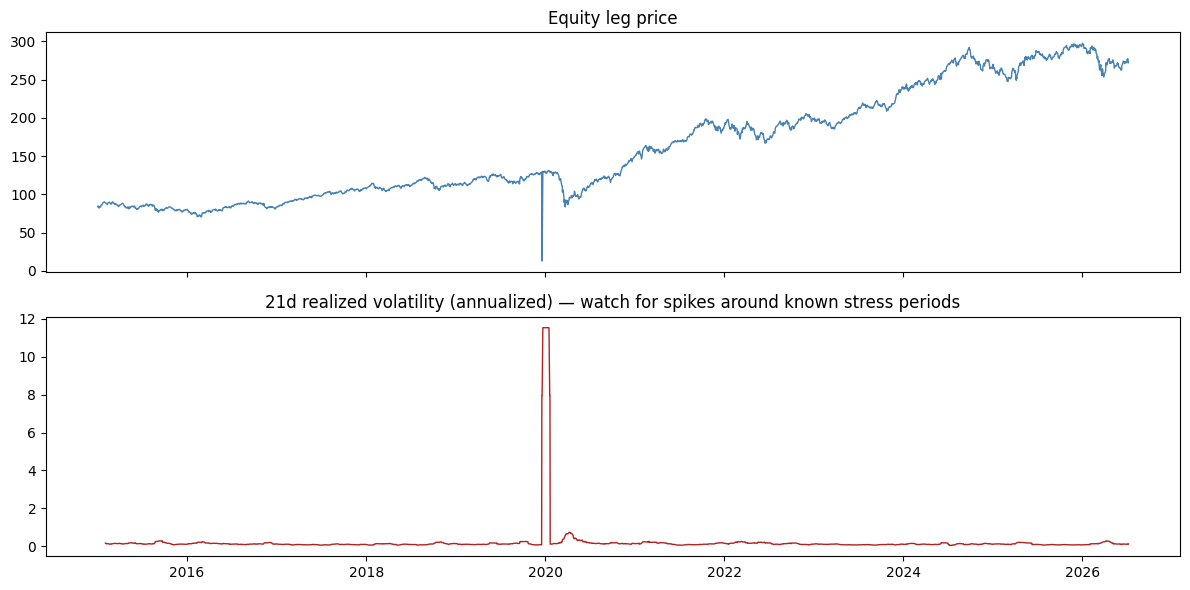

In [6]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(12, 6))
ax[0].plot(prices.index, prices["equity"], color="steelblue", lw=1)
ax[0].set_title("Equity leg price")
rolling_vol = asset_returns["equity"].rolling(21).std() * np.sqrt(252)
ax[1].plot(rolling_vol.index, rolling_vol, color="firebrick", lw=1)
ax[1].set_title("21d realized volatility (annualized) — watch for spikes around known stress periods")
plt.tight_layout()
plt.show()


## 3. Feature engineering

Momentum (5/21/63/126d) + realized volatility (5/21/63d) on the equity leg, plus the
raw VIX level. The HMM is fed a deliberately small subset — `mom_21d`, `vol_21d`,
`vix_level` — one direction feature and two stress/fear features, so the model has a
clean, low-dimensional signal to split into regimes rather than a noisy kitchen sink.

In [7]:
feat = build_feature_matrix(prices, vix, equity_col="equity")
feat[HMM_FEATURE_COLS + ["vol_21d"]].tail()


,mom_21d,vol_21d,vix_level,vol_21d
Date,,,,
2026-07-03,0.038818,0.107357,11.80,0.107357
2026-07-06,0.045485,0.107604,11.82,0.107604
2026-07-07,0.055187,0.098184,11.65,0.098184
2026-07-08,0.029597,0.123908,14.68,0.123908
2026-07-09,0.036795,0.123121,13.36,0.123121


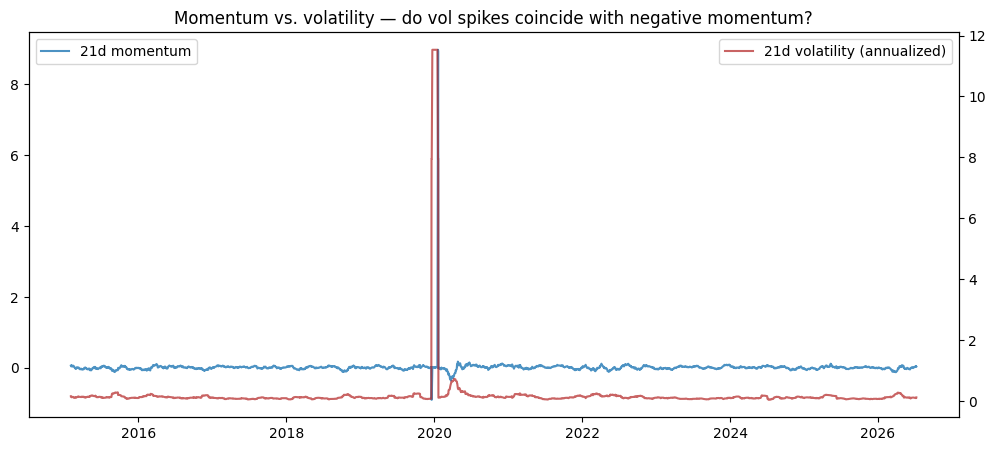

In [8]:
fig, ax = plt.subplots()
ax.plot(feat.index, feat["mom_21d"], label="21d momentum", alpha=0.8)
ax2 = ax.twinx()
ax2.plot(feat.index, feat["vol_21d"], label="21d volatility (annualized)", color="firebrick", alpha=0.7)
ax.set_title("Momentum vs. volatility — do vol spikes coincide with negative momentum?")
ax.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.show()


## 4. Walk-forward HMM regime detection

**Why walk-forward, specifically:** a single train/test split (or worse, fitting the
HMM on the *whole* dataset and just reading off labels) lets the model's notion of
"what counts as high volatility" be shaped by data the model would never have seen
in real time. `run_walk_forward_regimes` (in `src/backtest.py`) instead:

1. Splits the data into expanding-training / fixed-test folds (`src/walkforward.py`).
2. Inside each fold, fits z-score parameters **on the training slice only** and
   applies them to both halves.
3. Fits a fresh 3-state Gaussian HMM **on the training slice only**.
4. Decodes regimes on the **test slice only**, using that fold's own model.
5. Maps arbitrary HMM state indices (0/1/2) to Bull/Bear/Crisis using the
   *training* fold's volatility ranking (highest avg. vol → Crisis), so labels are
   meaningful without ever looking at test-set outcomes to assign them.

This directly satisfies the checklist requirement: *"a regime label assigned to a
given day should never have been influenced by data from after that day."*

In [9]:
# Fold sizing is auto-derived from however much data feat actually contains
# (src/walkforward.py::auto_walk_forward_config), rather than hard-coded to
# this specific date range. This is what keeps the walk-forward setup from
# breaking -- or silently overfitting its own split sizes -- if this notebook
# is later run on a shorter/longer/different 'unseen' date range.
# Pass explicit n_splits/min_train_size/test_size below if you want manual control.

regime_labels, transition_matrices = run_walk_forward_regimes(feat, n_states=3)
regime_labels.value_counts()


[walk-forward] auto-derived config from 2825 rows: n_splits=8, min_train_size=988, test_size=226
[walk-forward] fold 1/8: train=2015-02-02..2019-01-30 test=2019-01-31..2020-01-07 test regime counts={'Bear': 102, 'Crisis': 83, 'Bull': 41}
[walk-forward] fold 2/8: train=2015-02-02..2020-01-07 test=2020-01-08..2020-12-02 test regime counts={'Bear': 109, 'Bull': 108, 'Crisis': 9}
[walk-forward] fold 3/8: train=2015-02-02..2020-12-02 test=2020-12-03..2021-11-01 test regime counts={'Bull': 226}
[walk-forward] fold 4/8: train=2015-02-02..2021-11-01 test=2021-11-02..2022-09-28 test regime counts={'Bull': 226}
[walk-forward] fold 5/8: train=2015-02-02..2022-09-28 test=2022-09-29..2023-08-28 test regime counts={'Bull': 226}
[walk-forward] fold 6/8: train=2015-02-02..2023-08-28 test=2023-08-29..2024-08-01 test regime counts={'Bull': 226}
[walk-forward] fold 7/8: train=2015-02-02..2024-08-01 test=2024-08-02..2025-06-30 test regime counts={'Bull': 226}
[walk-forward] fold 8/8: train=2015-02-02..202

Bull      1505
Bear       211
Crisis      92
Name: count, dtype: int64

In [10]:
print("Transition matrix from the FINAL (most data) fold:")
final_transmat = pd.DataFrame(
    transition_matrices[-1],
    index=["from_state_0", "from_state_1", "from_state_2"],
    columns=["to_state_0", "to_state_1", "to_state_2"],
)
final_transmat


Transition matrix from the FINAL (most data) fold:


,to_state_0,to_state_1,to_state_2
from_state_0,9.996072e-01,0.000000,3.927730e-04
from_state_1,5.000000e-01,0.500000,2.145291e-138
from_state_2,2.494655e-71,0.047619,9.523810e-01


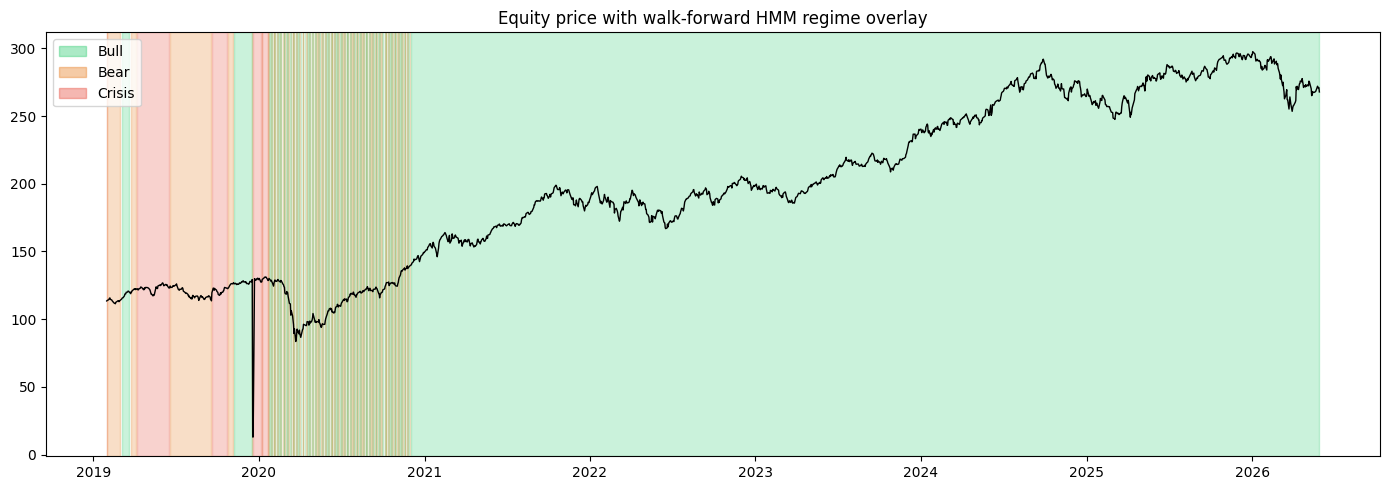

In [11]:
# Regime-overlay plot: this is the "does it visually line up with known
# turbulent periods" checkpoint the project brief calls out.
regime_colors = {"Bull": "#2ecc71", "Bear": "#e67e22", "Crisis": "#e74c3c"}

plot_prices = prices.loc[regime_labels.index, "equity"]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(plot_prices.index, plot_prices, color="black", lw=1, zorder=3)

# shade contiguous blocks of the same regime
lbls = regime_labels.values
start = 0
for i in range(1, len(lbls) + 1):
    if i == len(lbls) or lbls[i] != lbls[start]:
        ax.axvspan(regime_labels.index[start], regime_labels.index[i - 1],
                    color=regime_colors.get(lbls[start], "grey"), alpha=0.25)
        start = i

handles = [plt.Rectangle((0, 0), 1, 1, color=c, alpha=0.4) for c in regime_colors.values()]
ax.legend(handles, regime_colors.keys(), loc="upper left")
ax.set_title("Equity price with walk-forward HMM regime overlay")
plt.tight_layout()
plt.show()


## 5. Regime-conditional convex optimization (cvxpy)

Each rebalance solves the same mean-variance QP,

$$\max_w \; \mu^\top w - \lambda \, w^\top \Sigma w \quad \text{s.t.} \quad \mathbf{1}^\top w = 1,\; 0 \le w \le 0.7$$

with a **regime-dependent risk-aversion** \(\lambda\): low in Bull (behaves like a
Sharpe-maximizing tilt), high in Bear, very high in Crisis (behaves like minimum-variance
/ capital preservation). See `REGIME_RISK_AVERSION` in `src/optimize.py`. `mu`/`Sigma`
are estimated from a strictly trailing (never-future) 126-day window of realized asset
returns.

In [12]:
from src.optimize import REGIME_RISK_AVERSION
REGIME_RISK_AVERSION


{'Bull': 2.0, 'Bear': 8.0, 'Crisis': 25.0}

## 6. Backtest with transaction costs

Rebalances whenever the detected regime changes, or at least every 21 trading days
regardless (so weights don't go stale if a regime persists for a long stretch). A
5–10bps cost is applied to one-way turnover on every rebalance — this is what stops
the strategy from "secretly trading for free."

We report the strategy **with and without costs**, plus two frictionless, fixed-weight
benchmarks: static 60/40 (equity/bond) and equal-weight across all three assets.

In [13]:
LOOKBACK = 126
COST_BPS = 7.5
REBALANCE_EVERY = 21

common_idx = regime_labels.index.intersection(asset_returns.index)
regime_labels_bt = regime_labels.loc[common_idx]
asset_returns_bt = asset_returns.loc[common_idx]

result = run_backtest(asset_returns_bt, regime_labels_bt,
                       lookback=LOOKBACK, cost_bps=COST_BPS, rebalance_every=REBALANCE_EVERY)
result.tail()


,gross_return,cost,regime,net_return,w_equity,w_bond,w_gold
Date,,,,,,,
2026-05-25,0.000049,0.0,Bull,0.000049,0.0,0.321059,0.678941
2026-05-26,-0.004852,0.0,Bull,-0.004852,0.0,0.321040,0.678960
2026-05-27,-0.002832,0.0,Bull,-0.002832,0.0,0.322609,0.677391
2026-05-28,0.000000,0.0,Bull,0.000000,0.0,0.323522,0.676478
2026-05-29,-0.002048,0.0,Bull,-0.002048,0.0,0.323522,0.676478


In [14]:
sixty_forty = static_benchmark_returns(asset_returns_bt, {"equity": 0.6, "bond": 0.4, "gold": 0.0})
equal_wt = static_benchmark_returns(asset_returns_bt, {"equity": 1/3, "bond": 1/3, "gold": 1/3})

weights_cols = [c for c in result.columns if c.startswith("w_")]

summary = pd.DataFrame([
    performance_summary(result["net_return"], result[weights_cols], name="RegimeShift (net of costs)"),
    performance_summary(result["gross_return"], result[weights_cols], name="RegimeShift (gross, no costs)"),
    performance_summary(sixty_forty, name="Static 60/40"),
    performance_summary(equal_wt, name="Static Equal-Weight"),
]).set_index("Strategy")

summary.round(4)


,AnnReturn,AnnVol,Sharpe,Sortino,MaxDrawdown,Calmar,AvgDailyTurnover
Strategy,,,,,,,
RegimeShift (net of costs),NaN,4.2659,0.3554,1.8953,-15.3425,NaN,0.0227
"RegimeShift (gross, no costs)",NaN,4.2658,0.3562,1.8958,-15.7003,NaN,0.0227
Static 60/40,NaN,0.7342,0.1186,0.1129,-2.5649,NaN,NaN
Static Equal-Weight,NaN,1.2179,0.0994,0.0926,-10.6614,NaN,NaN


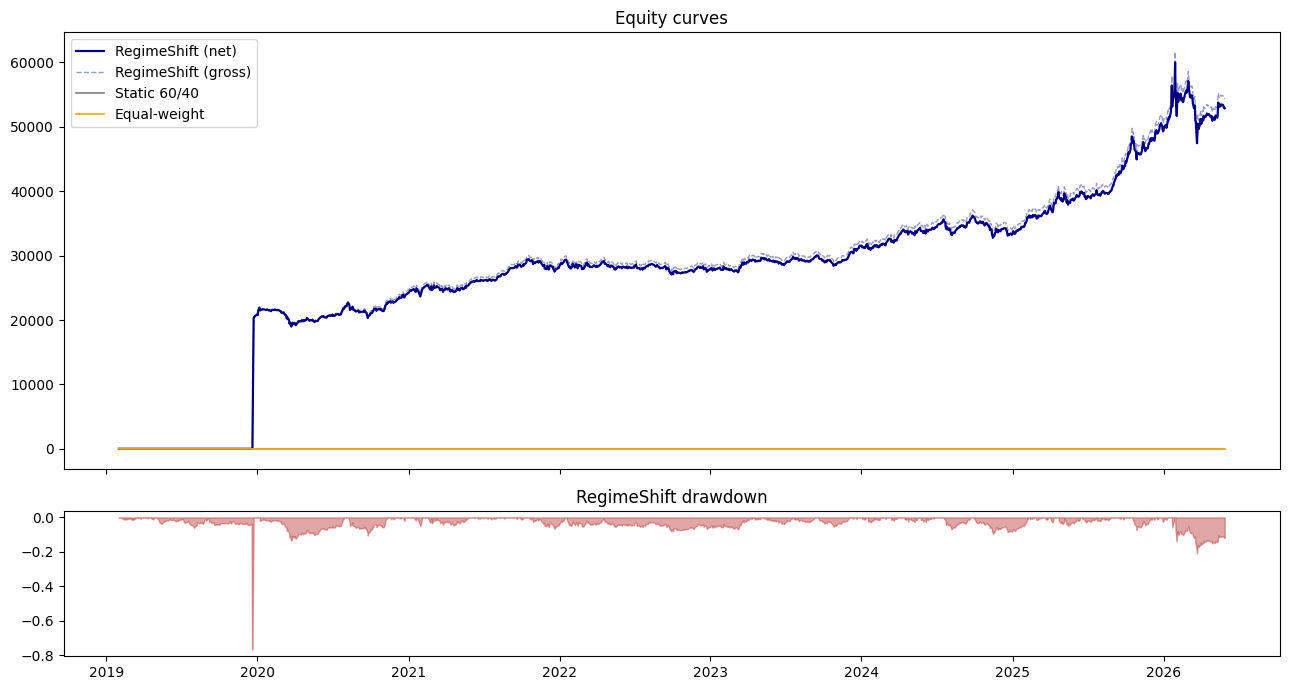

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True, gridspec_kw={"height_ratios": [3, 1]})

equity_curve = np.exp(result["net_return"].cumsum())
equity_curve_gross = np.exp(result["gross_return"].cumsum())
sixty_forty_curve = np.exp(sixty_forty.cumsum())
equal_wt_curve = np.exp(equal_wt.cumsum())

axes[0].plot(equity_curve.index, equity_curve, label="RegimeShift (net)", lw=1.6, color="navy")
axes[0].plot(equity_curve_gross.index, equity_curve_gross, label="RegimeShift (gross)", lw=1, color="navy", alpha=0.4, ls="--")
axes[0].plot(sixty_forty_curve.index, sixty_forty_curve, label="Static 60/40", lw=1.2, color="grey")
axes[0].plot(equal_wt_curve.index, equal_wt_curve, label="Equal-weight", lw=1.2, color="orange")
axes[0].set_title("Equity curves")
axes[0].legend()

running_max = equity_curve.cummax()
dd = equity_curve / running_max - 1
axes[1].fill_between(dd.index, dd, 0, color="firebrick", alpha=0.4)
axes[1].set_title("RegimeShift drawdown")
plt.tight_layout()
plt.show()


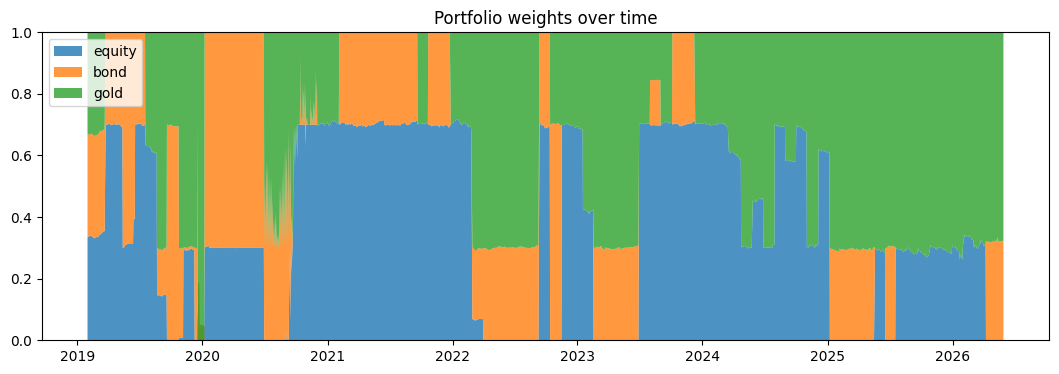

In [16]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.stackplot(result.index, [result[c] for c in weights_cols], labels=[c.replace("w_", "") for c in weights_cols], alpha=0.8)
ax.set_title("Portfolio weights over time")
ax.legend(loc="upper left")
ax.set_ylim(0, 1)
plt.show()


## 7. Results & takeaways

Read `summary` above for the final Sharpe / Sortino / MaxDrawdown / Calmar /
turnover comparison. A few things worth checking whenever you re-run this on fresh
data:

- **Gross vs. net gap** — if regime flips are frequent, the cost drag (`AvgDailyTurnover`)
  can meaningfully erode the Sharpe advantage over the static benchmarks. That's the
  point of reporting both.
- **Crisis-regime drawdown** — the dynamic strategy's `MaxDrawdown` during the Crisis-labeled
  stretches is the number that should look better than the static benchmarks', since
  that's the entire premise of regime-aware allocation.
- **Turnover sanity check** — if turnover is unrealistically high, increase
  `REBALANCE_EVERY` or make `REGIME_RISK_AVERSION` differences smaller so regime
  flips don't imply full portfolio overhauls.

See `README.md` for a discussion of remaining limitations (bond-proxy choice, HMM
state count, single train/test protocol vs. nested CV, etc.) and ideas for extending
this into a fully reproducible research pipeline.